<a href="https://colab.research.google.com/github/maashiross/samurai-terakoya/blob/main/%E6%9C%80%E7%B5%82%E8%AA%B2%E9%A1%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 自転車シェアリング需要データ分析レポート

# 1.はじめに

近年、都市部における移動手段として自転車シェアリングサービスが普及しており、その需要予測は運営効率化や都市計画において重要性を増しています。本資料では、Kaggle が提供する Bike Sharing Demand データセットを用いて、自転車利用数に影響を与える要因を分析します。

#2.解決したい社会課題
既存の調査では、天候・気温・曜日などが自転車シェアリング需要に影響することが示されています。しかし、**時間帯（hour）と気象条件の組み合わせが需要に与える影響**については十分に分析されていませんでした。
これらのデータを活用し、**時間帯 × 気象条件 × 気温**の観点から、自転車需要の特徴と課題を明らかにします。


#3.分析するデータ
Kaggle コンペティション「Bike Sharing Demand」の train.csv を使用します。 データには以下が含まれます。

•	datetime（日時）  
•	temp（気温）  
•	humidity（湿度）
•	weather（天候）  
•	season（季節）  
•	count（レンタル数）


#4.実行環境
•	パソコン：Dynabook windows11  
•	開発環境：Google Colaboratory  
•	言語：Python  
•	ライブラリ：Pandas、NumPy、Matplotlib、Seaborn、Scikit-learn

#5.分析の流れ
1.	データ読み込みと基本情報の確認
2.	日付・時間・季節・天候などの特徴量生成
3.	相関分析（ヒートマップ）
4.	モデル構築（Decision Tree / Random Forest）
5.	RMSE によるモデル評価
6.	結果の解釈と課題抽出


# 6.可視化したデータ

    • 相関ヒートマップ
        ◦ temp と count に正の相関
        ◦ humidity と count に弱い負の相関
        ◦ hour と count に強い相関（通勤時間帯に需要が集中）

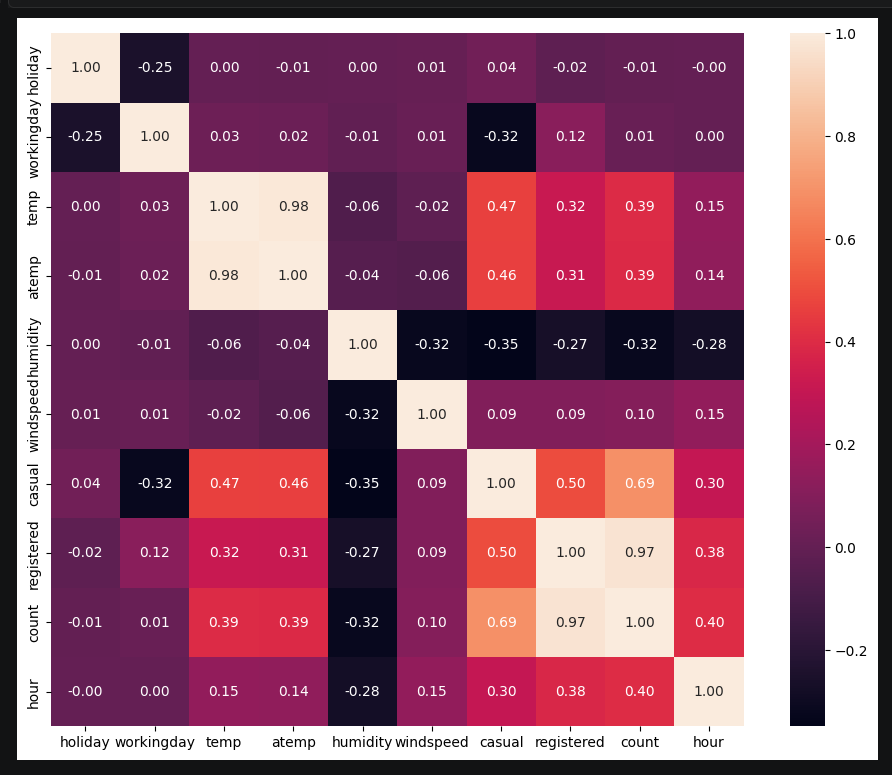

#7.分析したデータから得られた情報
**傾向**

•	気温が高いほど利用数が増える傾向

•	湿度が高いと利用数が減る傾向

•	朝 8 時、夕方 17〜18 時に利用がピーク（通勤需要）

**分類**

•	時間帯で分類すると

　　o	通勤ピーク帯（7〜9時、17〜19時）

　　o	日中帯（10〜16時）

　　o	深夜帯（0〜5時） に明確に分かれる。


•	天候で分類すると

　　o	晴れ・曇り → 利用多い

　　o	雨・雪 → 利用少ない




#8.課題
•	天候が悪化した際の需要変動が大きく、予測が難しい

•	時間帯による需要差が極端で、車両配置の最適化が必要

•	湿度や気温の変化に対する需要の感度が高い


#9.課題対策（予測精度向上）
さらに予測精度を向上させるため、Decision　Tree　で

学習、予測、評価を実施。評価はRMSEを使用した。

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error

# 1. モデルの作成
# max_depth: 木の深さ。深くしすぎると「過学習（Overfitting）」しやすくなるので注意
model_dt = DecisionTreeRegressor(random_state=42)

# 2. 学習
model_dt.fit(X_train, y_train)

# 3. 予測
y_pred_dt = model_dt.predict(X_test)

# 4. 評価
rmse_dt = root_mean_squared_error(y_test, y_pred_dt)

print(f"Decision Tree RMSE: {rmse_dt}")

Decision Tree RMSE: 144.69653064474866

さらに、RMSEを良化させるために、Random Forestで実施した。
評価は同様にRMSEを使用した。

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error

# 1. モデルのインスタンスを作成
# n_estimators: 作成する木の数（多いほど安定しますが計算時間がかかります）
# random_state: 結果を固定するためのシード値
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. モデルの学習
# y_trainが2次元(n, 1)の場合、.ravel()で1次元(n,)に変換すると警告が出なくなります
model_rf.fit(X_train, y_train.ravel())

# 3. 予測の実行
y_pred_rf = model_rf.predict(X_test)

# 4. RMSEの計算
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)

print(f"Random Forest RMSE: {rmse_rf}")


Random Forest RMSE: 119.97258377679991

Random　Forestにすることで、RMSEが145→120に良化した。

#10.考察
•	「通勤需要が自転車シェアリングの利用を大きく左右する」という仮説のもと分析した結果、hour と count の相関が最も高いことが確認されました。 また、RandomForest による予測精度（RMSE）が DecisionTree よりも高かったことから、複数の要因が複雑に絡む需要予測にはアンサンブル学習が有効と考えられます。


#11.まとめ
本分析から、以下の点が明らかになりました。
•	自転車シェアリング需要は 時間帯・気温・天候に強く依存する
•	特に 通勤時間帯の需要が突出して高い
•	RandomForest による予測が最も安定しており、需要予測モデルとして有効
•	天候悪化時の需要変動が課題であり、運営側の車両配置戦略に改善余地がある


#12.今後の改善案

**•	特徴量の拡張:**

 o	season, weather, weekday, month などもダミー変数化して追加

 o	休日フラグ、降水量、風速など外部データの統合

**•	モデルの高度化:**

o	ハイパーパラメータチューニング（GridSearchCV, RandomizedSearchCV）

o	XGBoost, LightGBM などの勾配ブースティング系モデルの導入

**•	可視化の強化:**

o	時間帯別・曜日別の平均レンタル数の折れ線グラフ

o	特徴量重要度の可視化（RandomForest の feature_importances_）

